# 5章演習2 タイタニック号の生存者分析

In [1]:
# 以下のライブラリを使うので、あらかじめ読み込んでおいてください
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# 相関比
def correlation_v(x, y):
    variation = ((y - y.mean()) ** 2).sum()
    inter_class = sum([((y[x == i] - y[x == i].mean()) ** 2).sum() for i in np.unique(x)])
    correlation_ratio = inter_class / variation
    return 1 - correlation_ratio

# クラメールの連関係数
def cramers_v(x, y):
    table = np.array(pd.crosstab(x, y)).astype(np.float32)
    n = table.sum()
    colsum = table.sum(axis=0)
    rowsum = table.sum(axis=1)
    expect = np.outer(rowsum, colsum) / n
    chisq = np.sum((table - expect) ** 2 / expect)
    return np.sqrt(chisq / (n * (np.min(table.shape) - 1)))

#スピアマンの順位相関比
def spearman(x, y):
    x = np.array(x)
    y= np.array(y)
    N = len(x)
    return 1 - (6*sum((x-y)**2) / (N*(N**2 - 1)))

## タイタニックデータの中身を確認してみよう

In [2]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 年齢の欠損値を補完してみよう
### 手順1.まずは欠損値があるか確認してみよう

pandasの関数を使って各カラムに欠損値があるか確認してみましょう.
年齢を含むいくつかのカラムに欠損値があるはずです。

In [3]:
titanic.isnull().any(axis=0)

survived       False
pclass         False
sex            False
age             True
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

### 手順2.欠損補完の関数を使ってみましょう

pandasの関数を使って「age」カラムの欠損値を平均値で埋めてみましょう。できたらもう一度欠損値があるか確認してください。

In [4]:
titanic["age"]=titanic["age"].fillna(int(titanic["age"].mean()))
titanic.isnull().any(axis=0)

survived       False
pclass         False
sex            False
age            False
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

### 手順3.もう一度、欠損値があるか確認してみましょう

In [5]:
titanic.isnull().any(axis=0)

survived       False
pclass         False
sex            False
age            False
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

## 今回使わないデータを削除してみよう

今回使わないsibsp・parch・fare・who・deckの列を削除してみましょう

In [6]:
titanic_test=titanic.drop(["sibsp","parch","fare","who","deck"],axis=1,inplace=False)
titanic_test.head()

,survived,pclass,sex,age,embarked,class,adult_male,embark_town,alive,alone
0,0,3,male,22.0,S,Third,True,Southampton,no,False
1,1,1,female,38.0,C,First,False,Cherbourg,yes,False
2,1,3,female,26.0,S,Third,False,Southampton,yes,True
3,1,1,female,35.0,S,First,False,Southampton,yes,False
4,0,3,male,35.0,S,Third,True,Southampton,no,True


## 自由に考察してみよう
### 各特徴と生存グラフの相関を求めよう

選んだ特徴と生存フラグの相関を見てみよう。

・年齢の場合<br>
　量的変数とカテゴリ変数の相関であるので相関比を用いて関係性を求めてみましょう。<br>
 &emsp;１に近いほど関連性が強く、一般的に0.1以上で関連性が認められます。

・性別の場合<br>
　名義尺度同士の相関であるのでクラメールの連関係数を用いて相関を求めてみましょう。<br>
 &emsp;１に近いほど関連性が強く、一般的に0.1以上で関連性が認められます。
 
 ・チケットクラスの場合<br>
　名義尺度と順序尺度の相関であるので順位相関比を用いて相関を求めてみましょう。<br>
 &emsp;１に近いほど関連性が強く、一般的に0.1以上で関連性が認められます。

・年齢の場合

In [7]:
correlation_v(titanic_test["survived"],titanic_test["age"])

0.004598717876202141

・性別の場合

In [8]:
cramers_v(titanic_test["survived"],titanic_test["sex"])

0.5433513740027712

・チケットクラスの場合

In [9]:
correlation_v(titanic_test["survived"],titanic_test["pclass"])

0.11456941170524215

## EX. それぞれの関係を可視化してみる

・年齢の場合

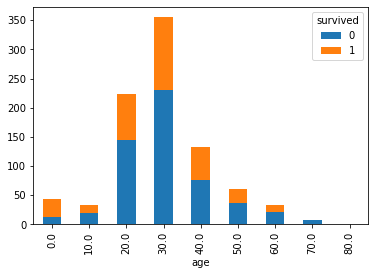

In [10]:
cross_age = pd.crosstab(titanic_test['survived'], round(titanic_test['age'],-1))
cross_age.T.plot(kind='bar', stacked=True)
plt.show()

(別解)より厳密には欠損値を補完せずに除いた方が適切なので、以下のようになってもよいと思います。

相関係数：0.005963097446925136


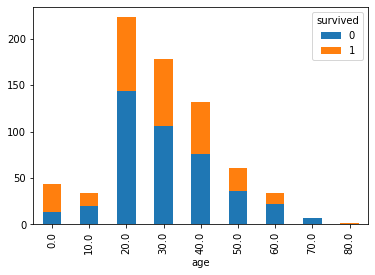

In [11]:
#欠損値を補完する前の元データを読み込みなおす
titanic_2 = sns.load_dataset('titanic')
#欠損値を補完するのではなく削除
titanic_2=titanic_2.dropna(subset=['age'])
#そのデータで相関係数を計算
v=correlation_v(titanic_2["survived"],titanic_2["age"])
print(f"相関係数：{v}")
cross_age = pd.crosstab(titanic_2['survived'], round(titanic_2['age'],-1))
cross_age.T.plot(kind='bar', stacked=True)
plt.show()

・性別の場合

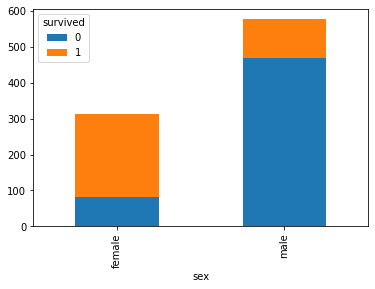

In [12]:
cross_sex =pd.crosstab(titanic_test['survived'], titanic_test['sex'])
cross_sex.T.plot(kind='bar', stacked=True)
plt.show()

・チケットクラスの場合

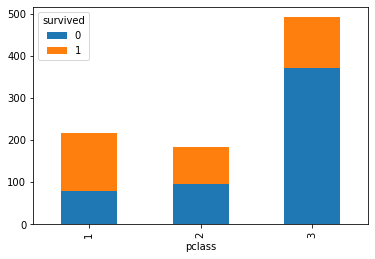

In [13]:
cross_pclass = pd.crosstab(titanic_test['survived'], titanic_test['pclass'])
cross_pclass.T.plot(kind='bar', stacked=True)
plt.show()

In [14]:
#生存率計算用
suviver=len(titanic_test[(titanic_test["pclass"]==3) & (titanic_test["survived"]==1)])
dead=len(titanic_test[(titanic_test["pclass"]==3) & (titanic_test["survived"]==0)])
(suviver/(suviver+dead))*100

24.236252545824847

In [15]:
#生存率計算用
suviver=len(titanic_2[(titanic_2["age"]>=10) & (titanic_2["survived"]==1)])
dead=len(titanic_2[(titanic_2["age"]>=10) & (titanic_2["survived"]==0)])
(suviver/(suviver+dead))*100

38.65030674846626